In [9]:
import pandas as pd

# Load CSV dataset
_df = pd.read_csv(r"E:\1st Semester\Machine Learning\Supervised Learning Assignment\Data\pollution_dataset.csv")

# Show first rows
print(_df.head())

# Show column names
print(_df.columns)

# Show dataset shape
print(_df.shape)

                  Date              City  Latitude  Longitude  PM2.5  PM10  \
0  2025-11-08 00:00:00  Lahore, Pakistan   31.5497    74.3436   81.0  82.7   
1  2025-11-08 01:00:00  Lahore, Pakistan   31.5497    74.3436   78.2  79.6   
2  2025-11-08 02:00:00  Lahore, Pakistan   31.5497    74.3436   75.4  76.8   
3  2025-11-08 03:00:00  Lahore, Pakistan   31.5497    74.3436   72.2  73.6   
4  2025-11-08 04:00:00  Lahore, Pakistan   31.5497    74.3436   69.8  71.2   

    NO2   SO2      CO  Ozone  Aerosol_Optical_Depth  AQI_Class  
0  94.0  16.4  1910.0   11.0                   0.19  Unhealthy  
1  90.9  14.4  1413.0   10.0                   0.19  Unhealthy  
2  85.0  12.8  1060.0   12.0                   0.19  Unhealthy  
3  72.8  11.8   863.0   20.0                   0.19  Unhealthy  
4  57.7  11.1   811.0   31.0                   0.19  Unhealthy  
Index(['Date', 'City', 'Latitude', 'Longitude', 'PM2.5', 'PM10', 'NO2', 'SO2',
       'CO', 'Ozone', 'Aerosol_Optical_Depth', 'AQI_Class'],
 

C:\Users\kiran\AppData\Local\Temp\ipykernel_14956\1594250933.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = _df.select_dtypes(include='object').columns
E:\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

LOGISTIC REGRESSION ACCURACY:
0.8618025751072962

DECISION TREE ACCURACY:
1.0

RANDOM FOREST ACCURACY:
1.0

MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression  0.861803
1        Decision Tree  1.000000
2        Random Forest  1.000000


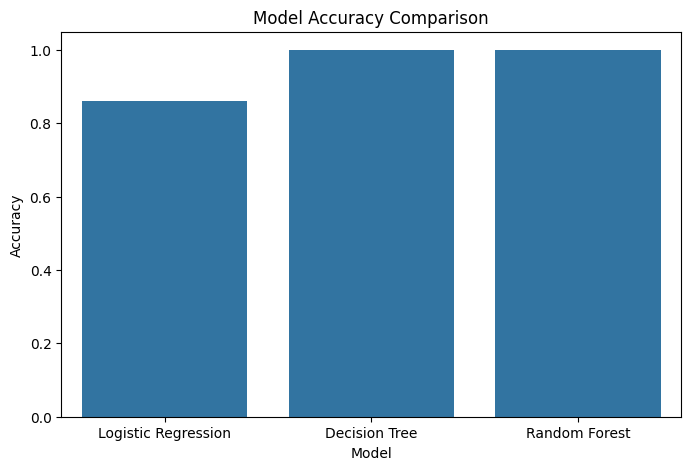

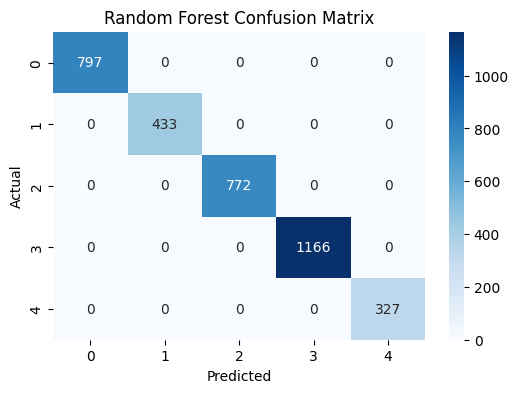


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       797
           1       1.00      1.00      1.00       433
           2       1.00      1.00      1.00       772
           3       1.00      1.00      1.00      1166
           4       1.00      1.00      1.00       327

    accuracy                           1.00      3495
   macro avg       1.00      1.00      1.00      3495
weighted avg       1.00      1.00      1.00      3495



In [10]:
# ==========================================
# MACHINE LEARNING MODELS
# ==========================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

# Fill numeric missing values
numeric_columns = _df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    _df[col] = _df[col].fillna(_df[col].median())

# Fill categorical missing values
categorical_columns = _df.select_dtypes(include='object').columns

for col in categorical_columns:
    _df[col] = _df[col].fillna(_df[col].mode()[0])

# ==========================================
# ENCODE CATEGORICAL VARIABLES
# ==========================================

label_encoder = LabelEncoder()

for col in categorical_columns:
    _df[col] = label_encoder.fit_transform(_df[col])

# ==========================================
# DEFINE FEATURES AND TARGET
# ==========================================

X = _df.drop(columns=['AQI_Class'])
y = _df['AQI_Class']

# ==========================================
# SPLIT DATA
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# MODEL 1 — LOGISTIC REGRESSION
# ==========================================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("LOGISTIC REGRESSION ACCURACY:")
print(lr_accuracy)

# ==========================================
# MODEL 2 — DECISION TREE
# ==========================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("\nDECISION TREE ACCURACY:")
print(dt_accuracy)

# ==========================================
# MODEL 3 — RANDOM FOREST
# ==========================================

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("\nRANDOM FOREST ACCURACY:")
print(rf_accuracy)

# ==========================================
# MODEL COMPARISON TABLE
# ==========================================

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

print("\nMODEL COMPARISON")
print(results)

# ==========================================
# ACCURACY BAR CHART
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title('Model Accuracy Comparison')

plt.savefig('../Figures/model_accuracy.png')

plt.show()

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig('../Figures/confusion_matrix.png')

plt.show()

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, rf_predictions))